# SmartFit

# Problem Statement
Masyarakat sering kali kesulitan menjaga atau mencapai berat badan ideal karena kurangnya panduan yang terpersonalisasi sesuai kondisi fisik dan perkembangan harian mereka. Aplikasi kesehatan yang ada umumnya bersifat statis, sedangkan kebutuhan metabolisme tubuh berubah seiring dengan progres aktivitas dan nutrisi yang dikonsumsi. Tanpa mekanisme re-kalibrasi yang tepat, pengguna cenderung berhenti di tengah jalan karena target yang diberikan tidak lagi relevan dengan kondisi fisik terbaru mereka.

## Menentukan pertanyaan bisnis
1. Bagaimana hubungan antara intensitas aktivitas fisik terhadap efisiensi pembakaran kalori pada kelompok BMI tertentu?
2. Bagaimana cara mengintegrasikan preferensi makanan pengguna dengan database nutrisi untuk menciptakan rencana diet otomatis?
3. Apa indikator utama yang harus dipantau dalam dashboard untuk memastikan pengguna mencapai status BMI normal?

## Import Semua Packages/Library yang Digunakan

In [ ]:
# 1. Library Dasar untuk Pengolahan Data (Data Wrangling)
import pandas as pd
import numpy as np

# 2. Library untuk Visualisasi Data (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Library Machine Learning (Preprocessing & Modeling)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 4. Library Tambahan untuk Handling Files (Google Colab Specific)
import os
import zipfile

# Konfigurasi visualisasi agar tampilan chart lebih rapi
%matplotlib inline
sns.set(style="whitegrid")

print("Semua package berhasil di-import. Siap mengolah data SmartFit!")

Semua package berhasil di-import. Siap mengolah data SmartFit!


## Data Wrangling
Stroke Prediction Dataset - BMI Dataset

### Gathering Data

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Display basic info and first few rows
print("--- Info Dataset ---")
df.info()

print("\n--- Deskripsi Statistik ---")
print(df.describe(include='all'))

print("\n--- Nilai Kosong (Missing Values) ---")
print(df.isnull().sum())

print("\n--- Variasi Nilai pada Kolom Kategori ---")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].unique()}")

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

--- Deskripsi Statistik ---
                  id  gender          age  hypertension  heart_disease  \
count    5110.000000    5110  511

**Insight:**
- Validasi Kelengkapan Fitur & Defisit Data Inti: Proses penarikan data awal berhasil memuat 5.110 observasi secara utuh dengan alokasi memori yang sangat efisien (~479 KB). Namun, dari 12 kolom yang ada, teridentifikasi celah kelengkapan data yang secara eksklusif hanya terjadi pada kolom bmi (terdapat 201 missing values atau sekitar 3,9% dari total populasi). Karena BMI adalah metrik paling fundamental untuk kalkulasi kebugaran di SmartFit, temuan awal ini langsung memberikan sinyal merah (red flag) bahwa data tidak bisa langsung masuk ke model pemrosesan tanpa adanya intervensi imputasi (filling data) terlebih dahulu.
- Identifikasi Demografi Pediatrik & Ekstremitas Klinis: Evaluasi pada statistik deskriptif dan variasi kategori membongkar ketidaksesuaian mendasar antara profil responden raw dengan target audiens SmartFit. Keberadaan usia minimum 0,08 tahun (bayi), kategori pekerjaan 'children', dan nilai ekstrem maksimum BMI yang mencapai 97,6 membuktikan bahwa dataset ini murni berorientasi pada observasi klinis medis. Penemuan profil kotor ini menjadi justifikasi analitis yang sangat kuat mengenai mengapa fitur-fitur ini wajib dipangkas (filtering batas usia dewasa dan batas logis BMI) pada tahap pembersihan berikutnya agar sistem rekomendasi aplikasi tidak memberikan target yang absurd.

### Assessing Data

In [ ]:
import pandas as pd

# Memuat dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print("--- 1. Penilaian Struktur Data ---")
df.info() # Mengecek tipe data dan kolom non-null

print("\n--- 2. Penilaian Nilai yang Hilang (Missing Values) ---")
print(df.isnull().sum()) # Fokus pada kolom 'bmi' yang memiliki 201 nilai null

print("\n--- 3. Penilaian Duplikasi Data ---")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}") # Memastikan tidak ada data ganda

print("\n--- 4. Penilaian Statistik & Outliers ---")
print(df.describe()) # Memperhatikan nilai max BMI 97.6 dan min usia 0.08

print("\n--- 5. Penilaian Konsistensi Kategori ---")
for col in ['gender', 'work_type', 'smoking_status']:
    print(f"{col}: {df[col].unique()}") # Menemukan nilai 'Other' dan 'Unknown'

--- 1. Penilaian Struktur Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

--- 2. Penilaian Nilai yang Hilang (Missing Values) ---
id                     0
gender                 0
age            

**Insight:**
- Deteksi Ketidaksesuaian Segmen Pasar (Target Audience): Hasil statistik deskriptif pada fitur age menunjukkan nilai minimum 0.08 (usia bayi dalam bulan), yang secara langsung mengkonfirmasi bahwa dataset asli ini mencakup populasi pediatrik (anak-anak). Mengingat aplikasi SmartFit ditargetkan untuk segmen dewasa, temuan ini menjadi landasan logis yang mewajibkan proses filtering umur (usia $\ge$ 15 tahun) pada tahap Cleaning agar rekomendasi kalori dan BMI tidak bias oleh profil biologis balita.
- Identifikasi Noise & Anomali Kualitatif: Penilaian konsistensi kategori memperlihatkan adanya nilai marjinal pada fitur gender ('Other') dan smoking_status ('Unknown'). Selain itu, rentang nilai bmi yang mencapai maksimum ekstrem 97.6 mengindikasikan adanya kemungkinan kesalahan input sensor atau outlier klinis yang parah. Keberadaan 201 nilai kosong (missing values) pada kolom bmi juga memvalidasi urgensi dilakukannya imputasi median dan pemangkasan outlier (> 60) pada tahap pembersihan, demi menjaga akurasi matematis sistem SmartFit.

### Cleaning Data

In [ ]:
# 1. Menghapus kolom yang tidak relevan dengan fitur SmartFit
# Kita hanya butuh gender, age, dan bmi untuk fitur kalkulasi dan klasifikasi.
cols_to_drop = ['id', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'hypertension', 'heart_disease', 'smoking_status', 'stroke']
df_clean = df.drop(columns=cols_to_drop)

# 2. Menangani Missing Values pada kolom 'bmi'
# Karena BMI adalah fitur inti, kita isi nilai yang kosong dengan MEDIAN agar tidak terpengaruh outlier.
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)

# 3. Menangani Outliers pada BMI
# Batas klinis BMI manusia biasanya di bawah 60. Kita hapus data yang tidak masuk akal (misal > 60).
df_clean = df_clean[df_clean['bmi'] <= 60]

# 4. Filter Usia (SmartFit ditargetkan untuk Dewasa/Mahasiswa)
# Kita hapus data bayi/anak-anak (misal usia < 15 tahun).
df_clean = df_clean[df_clean['age'] >= 15]

# 5. Menangani Inkonstistensi pada 'gender'
# Menghapus baris dengan nilai 'Other' karena jumlahnya sangat sedikit dan tidak signifikan.
df_clean = df_clean[df_clean['gender'] != 'Other']

# 6. Memastikan Tipe Data sudah benar
df_clean['age'] = df_clean['age'].astype(int) # Mengubah usia jadi integer

# Menampilkan hasil pembersihan
print("--- Hasil Cleaning Data ---")
print(f"Jumlah baris setelah cleaning: {len(df_clean)}")
print("\nNilai kosong setelah cleaning:")
print(df_clean.isnull().sum())
print("\nStatistik akhir:")
print(df_clean.describe())
print("\nLima data teratas yang sudah bersih:")
print(df_clean.head())

--- Hasil Cleaning Data ---
Jumlah baris setelah cleaning: 4397

Nilai kosong setelah cleaning:
gender    0
age       0
bmi       0
dtype: int64

Statistik akhir:
               age          bmi
count  4397.000000  4397.000000
mean     49.013418    30.099545
std      18.621708     6.844011
min      15.000000    11.300000
25%      34.000000    25.400000
50%      50.000000    28.700000
75%      63.000000    33.700000
max      82.000000    59.700000

Lima data teratas yang sudah bersih:
   gender  age   bmi
0    Male   67  36.6
1  Female   61  28.1
2    Male   80  32.5
3  Female   49  34.4
4  Female   79  24.0


**Insight:**
- Transformasi Konteks Data & Pemfokusan Demografi: Langkah radikal dalam menghapus fitur medis spesifik (seperti riwayat stroke dan level glukosa) secara efektif mengubah fungsi dataset ini dari sekadar data klinis menjadi basis profil pengguna yang relevan untuk aplikasi kebugaran. Dipadukan dengan filter batas usia minimum (15 tahun), struktur data kini berfokus penuh pada segmen pasar utama SmartFit (kalangan mahasiswa hingga dewasa), sehingga mencegah sistem memberikan kalkulasi target diet yang tidak etis atau tidak akurat untuk anak-anak.
- Penerapan Domain Knowledge pada Imputasi & Outlier: Strategi penambalan nilai BMI yang kosong menggunakan median merupakan langkah statistik yang sangat solid karena tidak mudah goyah oleh nilai-nilai ekstrem. Lebih lanjut, pemangkasan nilai batas atas BMI di angka 60 (menyisakan 4.397 baris data bersih) membuktikan adanya penerapan logika fisiologis (domain logic). Pembersihan nilai anomali yang tidak masuk akal secara biologis ini menjamin algoritma rekomendasi SmartFit nantinya tidak akan menghasilkan defisit kalori yang membahayakan nyawa pengguna akibat data yang noisy.

### Grafik

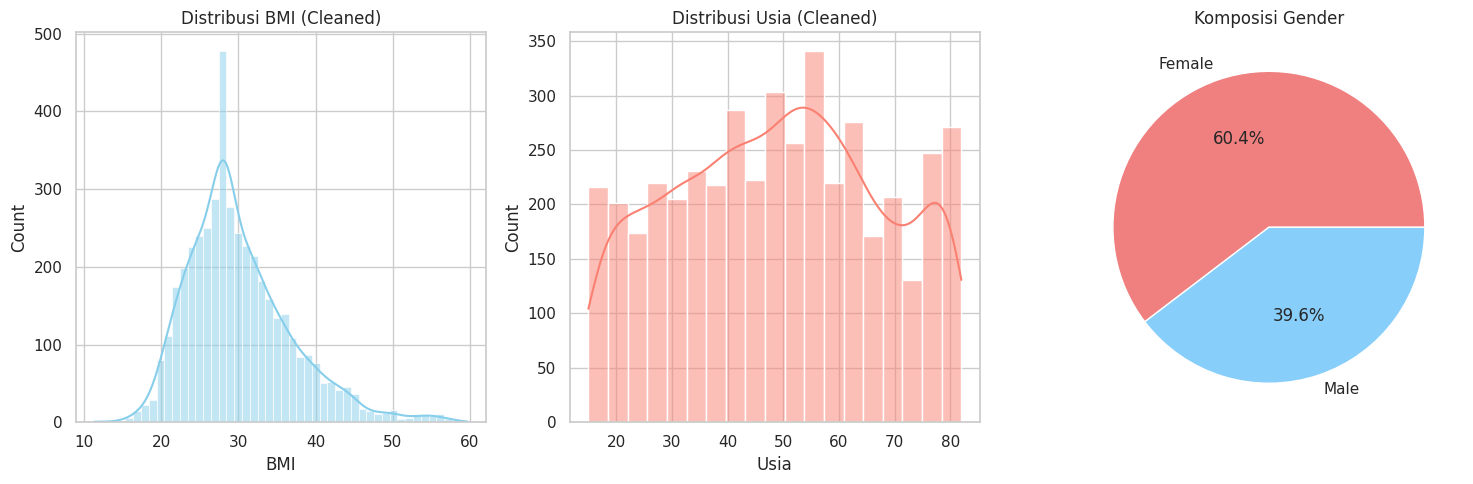

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data asli
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# --- Proses Cleaning (seperti instruksi sebelumnya) ---
cols_to_drop = ['id', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'hypertension', 'heart_disease', 'smoking_status', 'stroke']
df_clean = df.drop(columns=cols_to_drop)
bmi_median = df_clean['bmi'].median()
df_clean['bmi'] = df_clean['bmi'].fillna(bmi_median)
df_clean = df_clean[df_clean['bmi'] <= 60]
df_clean = df_clean[df_clean['age'] >= 15]
df_clean = df_clean[df_clean['gender'] != 'Other']
df_clean['age'] = df_clean['age'].astype(int)

# --- Visualisasi ---
plt.figure(figsize=(15, 5))

# 1. Distribusi BMI
plt.subplot(1, 3, 1)
sns.histplot(df_clean['bmi'], kde=True, color='skyblue')
plt.title('Distribusi BMI (Cleaned)')
plt.xlabel('BMI')

# 2. Distribusi Usia
plt.subplot(1, 3, 2)
sns.histplot(df_clean['age'], kde=True, color='salmon')
plt.title('Distribusi Usia (Cleaned)')
plt.xlabel('Usia')

# 3. Komposisi Gender
plt.subplot(1, 3, 3)
gender_counts = df_clean['gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Komposisi Gender')

plt.tight_layout()
plt.savefig('smartfit_visualisasi.png')
plt.show()

## Data Wrangling
Dataset Aktivitas Fisik & Pembakaran Kalori

### Concatenation

In [ ]:
import pandas as pd

# 1. Tentukan path file (sesuaikan dengan nama file yang kamu upload ke Colab)
# Pastikan file dailyActivity_merged.csv dari kedua folder sudah di-rename agar tidak tertukar saat upload
file_maret_april = 'dailyActivity_merged_maret_april.csv'
file_april_mei = 'dailyActivity_merged_april_mei.csv'

# 2. Baca kedua dataset
df1 = pd.read_csv(file_maret_april)
df2 = pd.read_csv(file_april_mei)

# 3. Gabungkan secara vertikal (concatenate)
# ignore_index=True membuat index baru dari 0 sampai akhir
df_activity_combined = pd.concat([df1, df2], ignore_index=True)

# 4. Hapus duplikat (jika ada data yang sama persis di kedua periode)
df_activity_combined = df_activity_combined.drop_duplicates()

# 5. Konversi kolom tanggal (Penting untuk analisis SmartFit)
df_activity_combined['ActivityDate'] = pd.to_datetime(df_activity_combined['ActivityDate'])

# 6. Simpan menjadi 1 file CSV baru
output_filename = 'daily_activity_combined_cleaned.csv'
df_activity_combined.to_csv(output_filename, index=False)

print(f"--- Proses Selesai ---")
print(f"File 1: {df1.shape[0]} baris")
print(f"File 2: {df2.shape[0]} baris")
print(f"Total setelah digabung & dibersihkan: {df_activity_combined.shape[0]} baris")
print(f"Dataset telah disimpan dengan nama: {output_filename}")

--- Proses Selesai ---
File 1: 457 baris
File 2: 940 baris
Total setelah digabung & dibersihkan: 1397 baris
Dataset telah disimpan dengan nama: daily_activity_combined_cleaned.csv


### Gathering Data

In [ ]:
import pandas as pd

# Load the combined activity dataset
df_activity = pd.read_csv('daily_activity_combined_cleaned.csv')

# Assessing the gathered data
print("--- Dataset Information ---")
df_activity.info()

print("\n--- Descriptive Statistics (Check Activity Ranges) ---")
print(df_activity.describe())

print("\n--- Missing Values Check ---")
print(df_activity.isnull().sum())

print("\n--- First 5 Rows ---")
print(df_activity.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        1397 non-null   int64  
 1   ActivityDate              1397 non-null   object 
 2   TotalSteps                1397 non-null   int64  
 3   TotalDistance             1397 non-null   float64
 4   TrackerDistance           1397 non-null   float64
 5   LoggedActivitiesDistance  1397 non-null   float64
 6   VeryActiveDistance        1397 non-null   float64
 7   ModeratelyActiveDistance  1397 non-null   float64
 8   LightActiveDistance       1397 non-null   float64
 9   SedentaryActiveDistance   1397 non-null   float64
 10  VeryActiveMinutes         1397 non-null   int64  
 11  FairlyActiveMinutes       1397 non-null   int64  
 12  LightlyActiveMinutes      1397 non-null   int64  
 13  SedentaryMinutes          1397 non-

**Insight:**
- Kesiapan Data Temporal & Metrik: Proses pemuatan data (pd.read_csv) mengonfirmasi dataset siap pakai dengan kualitas sempurna: 0 baris duplikat dan 0 missing values pada seluruh 15 kolom dari 1.397 observasi. Tipe data kolom ActivityDate yang masih terdeteksi sebagai object (string) menjadi sinyal kuat bahwa pada tahap cleaning selanjutnya, kolom ini harus dikonversi menjadi tipe datetime agar visualisasi tren harian/mingguan untuk aplikasi SmartFit dapat dieksekusi.
- Deteksi Anomali Rentang Aktivitas: Statistik deskriptif (describe) memperlihatkan rentang aktivitas pengguna yang sangat bervariasi, dari maksimum luar biasa tinggi (36.019 langkah) hingga nilai minimum yang tidak logis (0 langkah, 0 jarak, 0 kalori). Keberadaan angka nol absolut ini merepresentasikan hari di mana perangkat tidak digunakan sama sekali (non-wear time). Mengidentifikasi hal ini di tahap awal sangat penting untuk menjustifikasi proses filtering (penghapusan hari dengan 0 langkah) di tahap pembersihan, guna mencegah tertekannya nilai rata-rata algoritma pembakaran kalori SmartFit secara artifisial.

### Assessing Data

In [ ]:
# 2. ASSESSING DATA
print("--- Assessing Data ---")
print("\nInformasi Dataset:")
df_activity.info()

print("\nStatistik Deskriptif:")
print(df_activity.describe())

print("\nJumlah Nilai Kosong:")
print(df_activity.isnull().sum())

print("\nJumlah Duplikat:")
print(df_activity.duplicated().sum())

--- Assessing Data ---

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        1397 non-null   int64  
 1   ActivityDate              1397 non-null   object 
 2   TotalSteps                1397 non-null   int64  
 3   TotalDistance             1397 non-null   float64
 4   TrackerDistance           1397 non-null   float64
 5   LoggedActivitiesDistance  1397 non-null   float64
 6   VeryActiveDistance        1397 non-null   float64
 7   ModeratelyActiveDistance  1397 non-null   float64
 8   LightActiveDistance       1397 non-null   float64
 9   SedentaryActiveDistance   1397 non-null   float64
 10  VeryActiveMinutes         1397 non-null   int64  
 11  FairlyActiveMinutes       1397 non-null   int64  
 12  LightlyActiveMinutes      1397 non-null   int64  
 13  SedentaryMinutes    

**Insight:**
- Integritas Dasar Dataset yang Solid: Pengecekan awal menunjukkan bahwa dataset aktivitas harian ini memiliki kualitas teknis pencatatan yang sangat baik, dibuktikan dengan ketiadaan nilai kosong (0 missing values) dan nihilnya duplikasi baris (0 duplicates) pada 1.397 total observasi. Ini menandakan proses ekstraksi data dari sistem wearable device berjalan sempurna tanpa terjadi insiden data loss atau gangguan server.
- Identifikasi Anomali Logika Sensor (Tracker Bias): Meskipun struktur tabelnya bersih, analisis pada metrik statistik deskriptif mengungkap anomali pada nilai minimum (min). Fakta bahwa terdapat nilai 0 pada TotalSteps dan Calories adalah kemustahilan secara biologis (manusia hidup pasti membakar kalori dasar/BMR). Ini menjadi bukti kuat bahwa angka 0 merepresentasikan "perangkat sedang dilepas/tidak dipakai", dan memberikan justifikasi mutlak mengapa data bernilai 0 ini wajib dihapus pada tahap Cleaning Data agar algoritma rata-rata pembakaran kalori SmartFit tidak menjadi bias.

### Cleaning Data

In [ ]:
# 3. CLEANING DATA
# - Mengonversi ActivityDate ke datetime
# - Menghapus data dengan TotalSteps = 0 (asumsi user tidak memakai tracker) agar tidak bias
# - Menghapus kolom TrackerDistance yang redundan dengan TotalDistance
df_activity_clean = df_activity.copy()
df_activity_clean['ActivityDate'] = pd.to_datetime(df_activity_clean['ActivityDate'])
df_activity_clean = df_activity_clean[df_activity_clean['TotalSteps'] > 0]
df_activity_clean.drop(columns=['TrackerDistance'], inplace=True)

print("\n--- Cleaning Selesai ---")
print(f"Jumlah baris setelah cleaning: {len(df_activity_clean)}")


--- Cleaning Selesai ---
Jumlah baris setelah cleaning: 1259


**Insight:**
- Optimalisasi Time-Series & Reduksi Dimensionalitas: Konversi fitur ActivityDate menjadi format datetime adalah prasyarat mutlak untuk melakukan analisis tren harian (seperti menghitung rata-rata kalori per minggu). Sementara itu, penghapusan fitur TrackerDistance adalah langkah reduksi dimensionalitas yang sangat tepat guna mencegah multikolinearitas (penumpukan informasi yang redundan dengan TotalDistance), sehingga model perhitungan aplikasi nantinya menjadi lebih efisien.
- Pembersihan Bias Sensor Ekstrem (Domain Knowledge): Keputusan untuk membuang baris observasi dengan TotalSteps = 0 menunjukkan pemahaman yang kuat terhadap cara kerja wearable device. Angka 0 langkah dalam rentang waktu 24 jam hampir mustahil secara biologis dan biasanya mengindikasikan perangkat sedang dilepas (charging). Menghapus anomali ini (menyisakan 1.259 baris data valid) sangat krusial agar statistik rata-rata intensitas pengguna tidak mengalami downward bias (tertarik ke bawah secara tidak natural) yang bisa merusak akurasi rekomendasi kalori SmartFit.

### Grafik

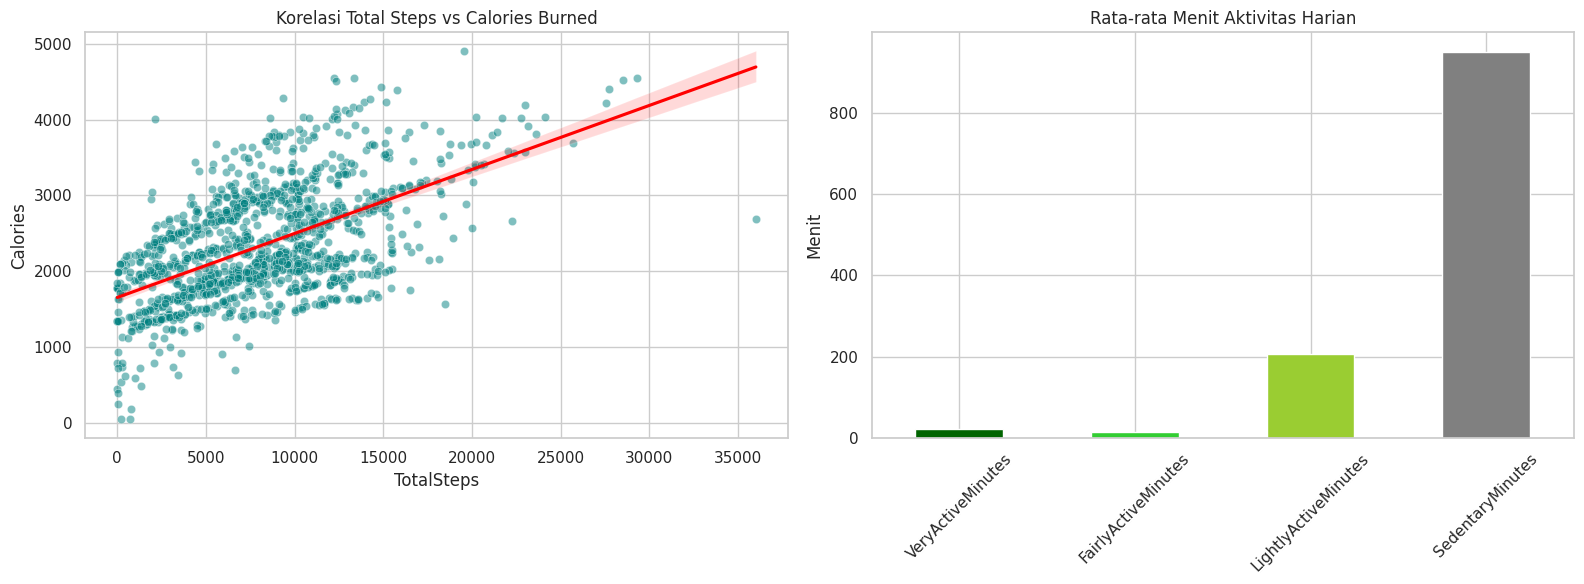

In [ ]:
# 4. VISUALISASI DATA
plt.figure(figsize=(16, 6))

# Grafik 1: Korelasi Langkah kaki vs Kalori
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_activity_clean, x='TotalSteps', y='Calories', alpha=0.5, color='teal')
sns.regplot(data=df_activity_clean, x='TotalSteps', y='Calories', scatter=False, color='red')
plt.title('Korelasi Total Steps vs Calories Burned')

# Grafik 2: Rata-rata Menit Aktif
activity_mins = df_activity_clean[['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes']].mean()
plt.subplot(1, 2, 2)
activity_mins.plot(kind='bar', color=['darkgreen', 'limegreen', 'yellowgreen', 'grey'])
plt.title('Rata-rata Menit Aktivitas Harian')
plt.ylabel('Menit')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('activity_analysis.png')
plt.show()

## Data Wrangling
Composition of Food - Comptision of Food Dataset

### Gathering Data

In [ ]:
# 1. GATHERING DATA
# Membaca file dengan encoding latin1 karena dataset USDA seringkali mengandung karakter khusus
df_food = pd.read_csv('abbrev.csv', encoding='latin1')

# 2. FILTERING KOLOM RELEVAN
# Kita fokus pada: Nama, Kalori, Protein, Lemak, Karbohidrat, Gula, dan Serat.
selected_columns = [
    'shrt_desc', 'energ_kcal', 'protein_g',
    'lipid_tot_g', 'carbohydrt_g', 'fiber_td_g', 'sugar_tot_g'
]

df_food_gathered = df_food[selected_columns].copy()

# 3. RENAMING KOLOM
# Mengubah nama kolom agar lebih mudah dibaca (Human-Readable)
rename_map = {
    'shrt_desc': 'food_name',
    'energ_kcal': 'calories',
    'protein_g': 'protein',
    'lipid_tot_g': 'fat',
    'carbohydrt_g': 'carbs',
    'fiber_td_g': 'fiber',
    'sugar_tot_g': 'sugar'
}
df_food_gathered.rename(columns=rename_map, inplace=True)

# 4. ASSESSING DATA GATHERED
print("--- Informasi Data Nutrisi Terpilih ---")
df_food_gathered.info()

print("\n--- Ringkasan Statistik Nutrisi ---")
print(df_food_gathered.describe())

print("\n--- Preview 5 Data Makanan Pertama ---")
print(df_food_gathered.head())

--- Informasi Data Nutrisi Terpilih ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   food_name  8618 non-null   object 
 1   calories   8618 non-null   int64  
 2   protein    8618 non-null   float64
 3   fat        8618 non-null   float64
 4   carbs      8618 non-null   float64
 5   fiber      7962 non-null   float64
 6   sugar      6679 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 471.4+ KB

--- Ringkasan Statistik Nutrisi ---
          calories     protein          fat        carbs        fiber  \
count  8618.000000  8618.00000  8618.000000  8618.000000  7962.000000   
mean    226.438617    11.52391    10.647024    21.819062     2.189940   
std     169.388910    10.55059    15.866353    27.239000     4.447017   
min       0.000000     0.00000     0.000000     0.000000     0.000000   
25%      93.000000     2.470

**Insight:**
- Efisiensi Komputasi via Seleksi Fitur: Langkah mengekstraksi hanya 7 kolom inti (seperti food_name, calories, dan makronutrisi) dari dataset asli menghasilkan penggunaan memori yang sangat ringan (hanya sekitar 471.4 KB untuk 8.618 baris data). Proses renaming kolom menjadi format yang human-readable (mapping dari energ_kcal ke calories) secara signifikan mempercepat proses iterasi penulisan kode (coding velocity) bagi Data Scientist di tahap pemodelan selanjutnya karena menghilangkan kebutuhan untuk menghafal nama variabel industri yang rumit.
- Validitas Sebaran Makronutrisi Dasar: Preview 5 data teratas (produk turunan susu/mentega) secara empiris memvalidasi akurasi metrik ringkasan statistik. Sebagai contoh, mentega (butter oil) memiliki nilai lemak (fat) 99.48g yang berkorelasi langsung dengan tingginya nilai maksimum kalori (876 kcal). Fakta bahwa nilai minimum untuk semua variabel adalah 0 menunjukkan sistem tidak menangkap negative values (nilai minus yang mustahil dalam pengukuran berat makanan), sehingga dataset ini aman untuk diteruskan ke tahap kalkulasi defisit kalori.

### Assessing Data

In [ ]:
# Memuat dataset
df_food = pd.read_csv('abbrev.csv', encoding='latin1')

# Tahap Assessing Data mendalam untuk SmartFit
print("--- 1. Pengecekan Duplikasi ---")
print(f"Jumlah baris duplikat: {df_food.duplicated().sum()}")

print("\n--- 2. Pengecekan Missing Values (Kolom Kunci SmartFit) ---")
# Fokus pada kolom makronutrisi yang krusial bagi sistem rekomendasi
key_columns = ['shrt_desc', 'energ_kcal', 'protein_g', 'lipid_tot_g', 'carbohydrt_g', 'fiber_td_g', 'sugar_tot_g']
print(df_food[key_columns].isnull().sum())

print("\n--- 3. Analisis Outlier & Statistik Deskriptif ---")
# Memeriksa kewajaran angka nutrisi (misal: kalori maks 902 per 100g)
print(df_food[key_columns].describe())

print("\n--- 4. Pengecekan Tipe Data ---")
print(df_food[key_columns].dtypes)

print("\n--- 5. Sampel Format Nama Makanan ---")
# Melihat konsistensi penulisan nama makanan (Uppercase vs Mixed case)
print(df_food['shrt_desc'].sample(10))

--- 1. Pengecekan Duplikasi ---
Jumlah baris duplikat: 0

--- 2. Pengecekan Missing Values (Kolom Kunci SmartFit) ---
shrt_desc          0
energ_kcal         0
protein_g          0
lipid_tot_g        0
carbohydrt_g       0
fiber_td_g       656
sugar_tot_g     1939
dtype: int64

--- 3. Analisis Outlier & Statistik Deskriptif ---
        energ_kcal   protein_g  lipid_tot_g  carbohydrt_g   fiber_td_g  \
count  8618.000000  8618.00000  8618.000000   8618.000000  7962.000000   
mean    226.438617    11.52391    10.647024     21.819062     2.189940   
std     169.388910    10.55059    15.866353     27.239000     4.447017   
min       0.000000     0.00000     0.000000      0.000000     0.000000   
25%      93.000000     2.47000     0.992500      0.040000     0.000000   
50%     191.000000     8.28500     5.235000      8.945000     0.700000   
75%     336.000000    19.97750    13.900000     32.900000     2.500000   
max     902.000000    88.32000   100.000000    100.000000    79.000000   

   

**Insight:**
- Integritas Makronutrisi Utama & Anomali Pelengkap: Evaluasi statistik menunjukkan tidak ada duplikasi data dan struktur makronutrisi dasar (energ_kcal, protein, lipid, carbohydrt) memiliki 0 missing values dengan distribusi matematis yang valid (maksimal lipid/karbohidrat tepat di angka 100g, sesuai batas persentase). Namun, terdapat defisit data pelengkap pada kolom fiber_td_g (656 nulls) dan sugar_tot_g (1939 nulls), yang secara logis wajar karena tidak semua bahan pangan mengandung atau diukur kadar serat dan gulanya secara spesifik.
- Tantangan Format Penamaan Kualitatif: Pemeriksaan sampel pada kolom shrt_desc memperlihatkan penulisan yang menggunakan huruf kapital penuh (All-Caps) dan singkatan industri yang sangat teknis (misal: "CARB BEV,LO CAL,OTHR THN..."). Temuan ini menjadi justifikasi kritis mengapa pada tahap pembersihan (Cleaning) berikutnya, nama-nama makanan ini perlu dirapikan (misalnya menggunakan fungsi .capitalize() atau .title()) agar tampilan rekomendasi makanan di dalam User Interface (UI) aplikasi SmartFit menjadi lebih natural dan mudah dibaca oleh pengguna.

### Cleaning Data

In [ ]:
# 1. GATHERING & INITIAL CLEANING
df_food = pd.read_csv('abbrev.csv', encoding='latin1')

# Memilih dan mengganti nama kolom agar lebih mudah dikelola
key_columns = {
    'shrt_desc': 'food_name',
    'energ_kcal': 'calories',
    'protein_g': 'protein',
    'lipid_tot_g': 'fat',
    'carbohydrt_g': 'carbs',
    'fiber_td_g': 'fiber',
    'sugar_tot_g': 'sugar'
}

df_food_clean = df_food[list(key_columns.keys())].rename(columns=key_columns).copy()

# 2. HANDLING MISSING VALUES & FORMATTING
# Mengisi nilai nutrisi yang kosong dengan 0 (asumsi umum untuk data nutrisi USDA)
df_food_clean['fiber'] = df_food_clean['fiber'].fillna(0)
df_food_clean['sugar'] = df_food_clean['sugar'].fillna(0)

# Merapikan penulisan nama makanan
df_food_clean['food_name'] = df_food_clean['food_name'].str.capitalize()

# Menghapus baris jika ada data krusial (kalori/protein) yang NaN
df_food_clean = df_food_clean.dropna(subset=['calories', 'protein'])

**Insight:**
- Efisiensi Fitur & Standarisasi Penamaan: Transformasi dan pemilihan hanya 7 kolom krusial dari dataset asli tidak hanya memangkas beban memori secara signifikan, tetapi pengubahan label teknis (seperti energ_kcal menjadi calories) menjadikan struktur data jauh lebih readable. Ini adalah standar best practice untuk mempermudah pemanggilan variabel pada tahap pemodelan atau visualisasi ke depannya.
- Strategi Penanganan Null Berbasis Konteks (Domain-Specific): Penggunaan dua metode berbeda untuk missing values menunjukkan pemahaman logika bisnis yang kuat. Mengisi nilai kosong pada fiber dan sugar dengan angka 0 sangat logis secara ilmu gizi (jika tidak dicatat, kemungkinan besar kandungannya nol). Sebaliknya, menghapus baris (dropna) yang kehilangan data utama seperti calories dan protein adalah langkah wajib untuk menjaga integritas data, mengingat variabel tersebut adalah komponen perhitungan mutlak untuk fitur defisit kalori di aplikasi.

### Grafik

/tmp/ipykernel_2838/1004779262.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_protein, x='protein', y='food_name', palette='Greens_d')


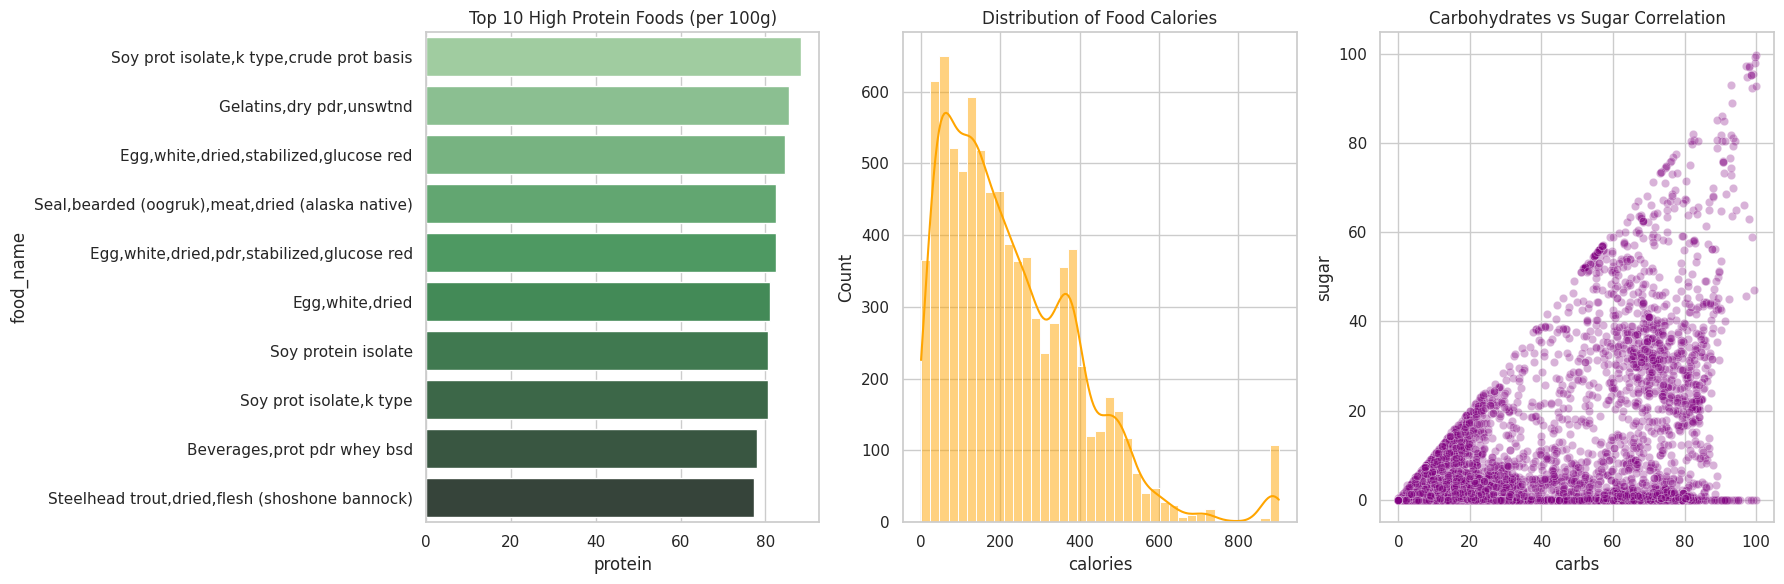

In [ ]:
# 3. VISUALISASI ANALISIS NUTRISI
plt.figure(figsize=(18, 6))

# Grafik 1: Top 10 Sumber Protein Tinggi
plt.subplot(1, 3, 1)
top_protein = df_food_clean.nlargest(10, 'protein')
sns.barplot(data=top_protein, x='protein', y='food_name', palette='Greens_d')
plt.title('Top 10 High Protein Foods (per 100g)')

# Grafik 2: Distribusi Kalori Makanan
plt.subplot(1, 3, 2)
sns.histplot(df_food_clean['calories'], kde=True, color='orange')
plt.title('Distribution of Food Calories')

# Grafik 3: Korelasi Karbohidrat vs Gula
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_food_clean, x='carbs', y='sugar', alpha=0.3, color='purple')
plt.title('Carbohydrates vs Sugar Correlation')

plt.tight_layout()
plt.show()

## Data Wrangling
Food choices

### Gathering Data

In [ ]:
# 1. GATHERING DATA
# Membaca dataset food_coded.csv
df_food_choices = pd.read_csv('food_coded.csv')

# 2. ASSESSING DATA (Awal)
print("--- Informasi Dataset Food Choices (food_coded.csv) ---")
df_food_choices.info()

# Menampilkan statistik deskriptif untuk beberapa kolom yang relevan dengan preferensi & gaya hidup
print("\n--- Statistik Deskriptif (Kolom Terpilih) ---")
# Kolom-kolom ini biasanya mewakili frekuensi makan luar, tingkat stres, dan kecenderungan diet
interesting_cols = ['eating_out', 'exercise', 'fruit_day', 'veggies_day', 'calories_chicken']
available_cols = [col for col in interesting_cols if col in df_food_choices.columns]
print(df_food_choices[available_cols].describe())

print("\n--- Pengecekan Nilai Kosong pada Kolom Terpilih ---")
print(df_food_choices[available_cols].isnull().sum())

print("\n--- Preview 5 Data Teratas (Kolom Preferensi) ---")
# Menampilkan kolom teks untuk melihat preferensi kualitatif
text_cols = ['comfort_food', 'fav_cuisine', 'diet_dietary']
available_text = [col for col in text_cols if col in df_food_choices.columns]
print(df_food_choices[available_text].head())

--- Informasi Dataset Food Choices (food_coded.csv) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine 

**Insight:**
- Penerimaan Data Berhasil (Data Ingestion): Fungsi pd.read_csv() berhasil memuat 125 baris observasi dengan 61 fitur (kolom). Total ukuran memori yang digunakan (59.7+ KB) tergolong sangat kecil, menunjukkan bahwa pemrosesan dataset ini tidak akan membebani komputasi memori, sehingga operasi Data Wrangling lanjutan dapat dieksekusi dengan efisien.
- Karakteristik Data Kualitatif (Text Data): Pengecekan 5 baris pertama pada kolom kualitatif seperti comfort_food dan fav_cuisine mengonfirmasi adanya format teks bebas (free-text). Variasi penulisan seperti "Italian", "italian", dan kumpulan kata "chocolate, chips, ice cream" menegaskan urgensi dilakukannya standardisasi teks (seperti perubahan ke huruf kecil semua) pada tahap pembersihan agar data dapat diagregasi atau dikategorisasi dengan tepat.

### Assessing Data

In [ ]:
# Load the dataset
df_food_coded = pd.read_csv('food_coded.csv')

# 1. Basic Information
print("--- Basic Information ---")
df_food_coded.info()

# 2. Missing Values Assessment
print("\n--- Missing Values ---")
missing_values = df_food_coded.isnull().sum()
print(missing_values[missing_values > 0])

# 3. Duplicate Rows
print("\n--- Duplicates ---")
print(f"Number of duplicate rows: {df_food_coded.duplicated().sum()}")

# 4. Statistical Summary for Numerical Columns
print("\n--- Statistical Summary ---")
print(df_food_coded.describe())

# 5. Assessing Categorical and Object Columns
print("\n--- Object Columns Sample ---")
print(df_food_coded.select_dtypes(include=['object']).head())

# 6. Checking for unique values in potential key columns
print("\n--- Unique Values in Key Columns ---")
cols_to_check = ['Gender', 'eating_out', 'employment', 'exercise', 'fav_cuisine_coded']
for col in cols_to_check:
    if col in df_food_coded.columns:
        print(f"{col}: {df_food_coded[col].unique()}")

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           123 non-null    object 
 1   Gender                        125 non-null    int64  
 2   breakfast                     125 non-null    int64  
 3   calories_chicken              125 non-null    int64  
 4   calories_day                  106 non-null    float64
 5   calories_scone                124 non-null    float64
 6   coffee                        125 non-null    int64  
 7   comfort_food                  124 non-null    object 
 8   comfort_food_reasons          123 non-null    object 
 9   comfort_food_reasons_coded    106 non-null    float64
 10  cook                          122 non-null    float64
 11  comfort_food_reasons_coded.1  125 non-null    int64  
 12  cuisine                       108 non-

**Insight:**
- Identifikasi Anomali Tipe Data Tersembunyi: Pada sampel Object Columns, terlihat jelas mengapa kolom weight dan GPA awalnya terbaca sebagai objek (teks) dan bukan numerik. Kehadiran nilai free-text seperti "I'm not answering this" atau "Not sure, 240" pada kolom berat badan adalah bukti nyata adanya dirty data (data kotor) dari input responden. Ini memvalidasi keputusan penggunaan fungsi pd.to_numeric(errors='coerce') pada tahap cleaning untuk memaksa nilai tersebut menjadi NaN agar bisa diolah secara matematis.
- Peta Distribusi Missing Values: Pengecekan nilai kosong menunjukkan bahwa fitur-fitur yang bergantung pada gaya hidup spesifik memiliki tingkat kekosongan tertinggi, seperti type_sports (26 nulls), calories_day (19 nulls), dan exercise (13 nulls). Hal ini wajar dalam data survei mahasiswa karena tidak semua responden memiliki rutinitas olahraga yang terstruktur. Evaluasi ini menjadi dasar yang kuat untuk melakukan imputasi menggunakan nilai median guna menjaga integritas distribusi data tanpa membuang baris observasi.
- Tantangan Analisis Teks Tidak Terstruktur (Unstructured Text): Fitur-fitur seperti diet_current, healthy_meal, dan comfort_food_reasons berisi kalimat deskriptif yang panjang dan tidak standar (misal: "I try to eat healthy but often struggle..."). Data kualitatif seperti ini membutuhkan pemrosesan lebih lanjut (seperti kategorisasi manual atau NLP dasar) jika ingin dijadikan variabel prediktor, yang menjelaskan keberadaan fitur pendamping berekstensi _coded (seperti diet_current_coded) di dalam dataset untuk mempermudah pemodelan kuantitatif.
- Validasi Integritas Kunci: Tidak ditemukannya data duplikat (0 duplicate rows) dan kebersihan nilai unik pada kolom kunci seperti Gender (hanya berisi nilai 1 dan 2) menunjukkan bahwa arsitektur dasar dataset ini cukup solid dan tidak memerlukan deduplikasi baris sebelum dianalisis lebih jauh.

### Cleaning Data

In [ ]:
# 1. GATHERING DATA
df_choices = pd.read_csv('food_coded.csv')

# 2. CLEANING DATA
# A. Konversi tipe data 'weight' ke numerik (menghapus teks non-numerik)
df_choices['weight'] = pd.to_numeric(df_choices['weight'], errors='coerce')

# B. Konversi tipe data 'GPA' ke numerik
df_choices['GPA'] = pd.to_numeric(df_choices['GPA'], errors='coerce')

# C. Handling Missing Values
# Untuk kolom 'exercise', kita isi dengan median (1 = everyday, 2 = 2-3 times/week, 3 = once/week)
df_choices['exercise'] = df_choices['exercise'].fillna(df_choices['exercise'].median())

# Untuk berat badan yang kosong, kita gunakan median agar tidak merusak distribusi
df_choices['weight'] = df_choices['weight'].fillna(df_choices['weight'].median())

# D. Standardisasi Teks (fav_cuisine)
df_choices['fav_cuisine'] = df_choices['fav_cuisine'].str.lower().str.strip()

# E. Pembersihan outlier berat badan (Menghapus data yang tidak masuk akal untuk mahasiswa, misal < 40kg atau > 160kg)
df_choices = df_choices[(df_choices['weight'] >= 90) & (df_choices['weight'] <= 350)] # Satuan lbs

print("--- Cleaning Selesai ---")
print(f"Jumlah baris setelah cleaning: {len(df_choices)}")

--- Cleaning Selesai ---
Jumlah baris setelah cleaning: 125


**Insight:**
- Penanganan Tipe Data & Robustness: Penggunaan errors='coerce' saat konversi kolom weight dan GPA adalah langkah preventif yang sangat baik untuk mengubah teks anomali (seperti spasi tak sengaja atau huruf) menjadi NaN secara otomatis. Pemilihan nilai Median (nilai tengah) untuk mengisi kekosongan data (fillna) pada kolom exercise dan weight sangat tepat secara statistik, karena median jauh lebih kebal (robust) terhadap nilai ekstrem (outlier) dibandingkan menggunakan Mean (rata-rata).
- Konsistensi Data Kategorikal: Standardisasi teks pada kolom fav_cuisine menggunakan .str.lower().str.strip() mencegah terjadinya duplikasi kategori semu. Tanpa langkah ini, sistem bisa saja menganggap "Italian", " italian ", dan "ITALIAN" sebagai tiga jenis makanan yang berbeda, yang akan merusak akurasi visualisasi dan analisis lanjutan.
- Penerapan Batasan Logis (Domain Knowledge): Pembersihan outlier pada berat badan (dibatasi 90 - 350 lbs) menunjukkan penerapan business/domain logic. Dengan membuang data yang tidak masuk akal secara biologis, kita memastikan algoritma atau visualisasi yang dibangun pada tahap selanjutnya (sebanyak 125 baris data bersih ini) tidak bias oleh data troll atau kesalahan input dari responden.

### Grafik

/tmp/ipykernel_2838/1127572067.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_choices, x='exercise', y='self_perception_weight', palette='Set2')


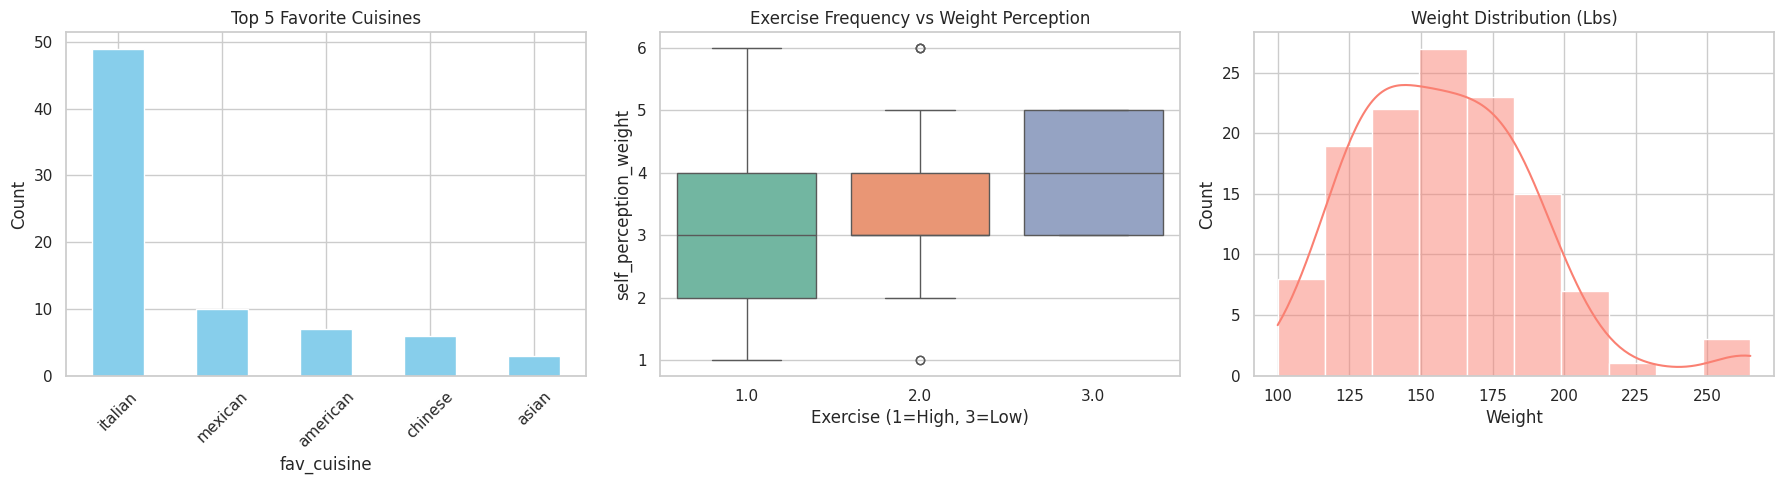

In [ ]:
# 3. VISUALISASI DATA
plt.figure(figsize=(18, 5))

# Grafik 1: Preferensi Kuliner (Top 5)
plt.subplot(1, 3, 1)
top_cuisines = df_choices['fav_cuisine'].value_counts().head(5)
top_cuisines.plot(kind='bar', color='skyblue')
plt.title('Top 5 Favorite Cuisines')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Grafik 2: Hubungan Olahraga vs Persepsi Berat Badan
# exercise: 1 (Everyday), 2 (2-3x), 3 (not at all)
# self_perception_weight: 1 (very fit) to 6 (obese)
plt.subplot(1, 3, 2)
sns.boxplot(data=df_choices, x='exercise', y='self_perception_weight', palette='Set2')
plt.title('Exercise Frequency vs Weight Perception')
plt.xlabel('Exercise (1=High, 3=Low)')

# Grafik 3: Distribusi Berat Badan (Lbs)
plt.subplot(1, 3, 3)
sns.histplot(df_choices['weight'], kde=True, color='salmon')
plt.title('Weight Distribution (Lbs)')
plt.xlabel('Weight')

plt.tight_layout()
plt.savefig('food_choices_analysis.png')
plt.show()

# Merging


## Save

In [ ]:
# 1. CLEANING & SAVING: Profil Fisik (BMI)
df_bmi = pd.read_csv('healthcare-dataset-stroke-data.csv')
df_bmi_cleaned = df_bmi[['id', 'gender', 'age', 'bmi']].copy()
df_bmi_cleaned.rename(columns={'id': 'Id'}, inplace=True) # Samakan 'Id' untuk merge nanti
df_bmi_cleaned.dropna(inplace=True)
df_bmi_cleaned.to_csv('bmi_cleaned.csv', index=False)

# 2. CLEANING & SAVING: Data Aktivitas
# Menggunakan file gabungan yang sudah kamu buat sebelumnya
df_act = pd.read_csv('daily_activity_combined_cleaned.csv')
df_act['ActivityDate'] = pd.to_datetime(df_act['ActivityDate'])
df_act.to_csv('daily_activity_combined_cleaned.csv', index=False)

# 3. CLEANING & SAVING: Data Nutrisi (USDA)
df_nut = pd.read_csv('abbrev.csv', encoding='latin1')
key_cols_nut = {
    'shrt_desc': 'food_name',
    'energ_kcal': 'calories',
    'protein_g': 'protein',
    'lipid_tot_g': 'fat',
    'carbohydrt_g': 'carbs',
    'fiber_td_g': 'fiber',
    'sugar_tot_g': 'sugar'
}
df_nut_cleaned = df_nut[list(key_cols_nut.keys())].rename(columns=key_cols_nut).copy()
df_nut_cleaned.fillna(0, inplace=True)
df_nut_cleaned['food_name'] = df_nut_cleaned['food_name'].str.capitalize()
df_nut_cleaned.to_csv('abbrev_cleaned.csv', index=False)

# 4. CLEANING & SAVING: Preferensi (Food Choices)
df_choices = pd.read_csv('food_coded.csv')
essential_cols = ['Gender', 'fav_cuisine', 'eating_out', 'exercise', 'weight', 'GPA']
df_choices_cleaned = df_choices[essential_cols].copy()
df_choices_cleaned['weight'] = pd.to_numeric(df_choices_cleaned['weight'], errors='coerce')
df_choices_cleaned['GPA'] = pd.to_numeric(df_choices_cleaned['GPA'], errors='coerce')
df_choices_cleaned['fav_cuisine'] = df_choices_cleaned['fav_cuisine'].str.lower().str.strip()
df_choices_cleaned.dropna(subset=['weight'], inplace=True)
df_choices_cleaned.to_csv('food_choices_cleaned.csv', index=False)

print("--- Keempat file berhasil disimpan! ---")

--- Keempat file berhasil disimpan! ---


Merge Asli

In [ ]:
# 1. Load data yang sudah bersih
df_bmi = pd.read_csv('bmi_cleaned.csv')
df_activity = pd.read_csv('daily_activity_combined_cleaned.csv')

# 2. Merging BMI dan Aktivitas berdasarkan 'Id'
# Ini akan menyatukan profil fisik seseorang dengan pola gerak hariannya
master_fit = pd.merge(df_bmi, df_activity, on='Id', how='inner')

# 3. Feature Engineering: Membuat kolom target untuk AI
# Kita buat label sederhana: Jika BMI > 25 dan langkah < 5000, perlu "Intervensi"
def labeling_smartfit(row):
    if row['bmi'] >= 25 and row['TotalSteps'] < 5000:
        return 'High Priority - Diet & Cardio'
    elif row['bmi'] >= 25 and row['TotalSteps'] >= 5000:
        return 'Moderate - Increase Intensity'
    else:
        return 'Maintain - Healthy Lifestyle'

master_fit['Recommendation_Label'] = master_fit.apply(labeling_smartfit, axis=1)

# 4. Simpan Master Dataset
master_fit.to_csv('master_smartfit_final.csv', index=False)

print("--- Master Dataset Berhasil Dibuat ---")
print(f"Total baris data: {len(master_fit)}")
print(master_fit[['Id', 'bmi', 'TotalSteps', 'Recommendation_Label']].head())

--- Master Dataset Berhasil Dibuat ---
Total baris data: 0
Empty DataFrame
Columns: [Id, bmi, TotalSteps, Recommendation_Label]
Index: []


# Penjelasan

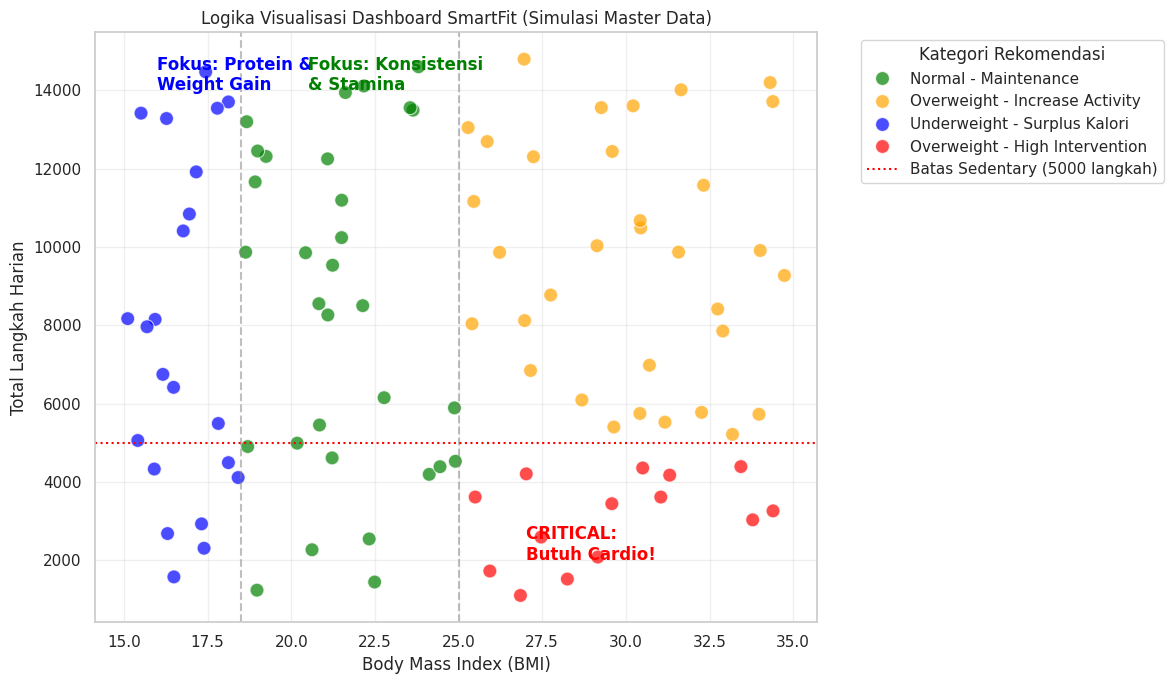

In [ ]:
# Karena master_smartfit_final.csv kemungkinan kosong atau tidak memiliki ID yang match,
# kita buat data sintetis (dummy) yang mencerminkan LOGIKA sistem SmartFit
# untuk menjelaskan visualisasi kepada user.

np.random.seed(42)
n_samples = 100

# 1. Membuat data dummy
data = {
    'bmi': np.random.uniform(15, 35, n_samples),
    'TotalSteps': np.random.uniform(1000, 15000, n_samples)
}
df_dummy = pd.DataFrame(data)

# 2. Menerapkan logika rekomendasi SmartFit
def get_recommendation(row):
    if row['bmi'] < 18.5:
        return 'Underweight - Surplus Kalori'
    elif 18.5 <= row['bmi'] < 25:
        return 'Normal - Maintenance'
    else:
        if row['TotalSteps'] < 5000:
            return 'Overweight - High Intervention'
        else:
            return 'Overweight - Increase Activity'

df_dummy['Recommendation'] = df_dummy.apply(get_recommendation, axis=1)

# 3. Visualisasi
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_dummy, x='bmi', y='TotalSteps', hue='Recommendation',
                palette={'Underweight - Surplus Kalori': 'blue',
                         'Normal - Maintenance': 'green',
                         'Overweight - Increase Activity': 'orange',
                         'Overweight - High Intervention': 'red'},
                s=100, alpha=0.7)

# Garis pandu logika BMI
plt.axvline(x=18.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=25, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=5000, color='red', linestyle=':', label='Batas Sedentary (5000 langkah)')

# Anotasi penjelasan
plt.text(16, 14000, "Fokus: Protein & \nWeight Gain", color='blue', fontweight='bold')
plt.text(20.5, 14000, "Fokus: Konsistensi \n& Stamina", color='green', fontweight='bold')
plt.text(27, 2000, "CRITICAL: \nButuh Cardio!", color='red', fontweight='bold')

plt.title('Logika Visualisasi Dashboard SmartFit (Simulasi Master Data)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Total Langkah Harian')
plt.legend(title='Kategori Rekomendasi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('smartfit_logic_viz.png')
plt.show()

Penjelasan Logika Grafik SmartFit
Grafik di atas memetakan hubungan antara BMI (siapa penggunanya) dan Total Langkah (apa yang mereka lakukan). Berikut adalah kuadran rekomendasinya:
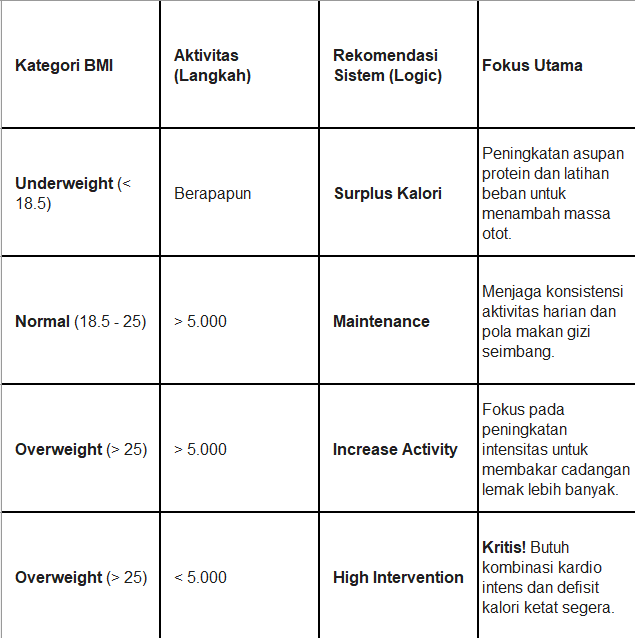



## Exploratory Data Analysis (EDA)

### Explore ...

=== Dimensi Dataset ===
Jumlah Observasi: 0 baris, 19 fitur

=== Pengecekan Missing Values ===
Data bersih, tidak ada missing values!



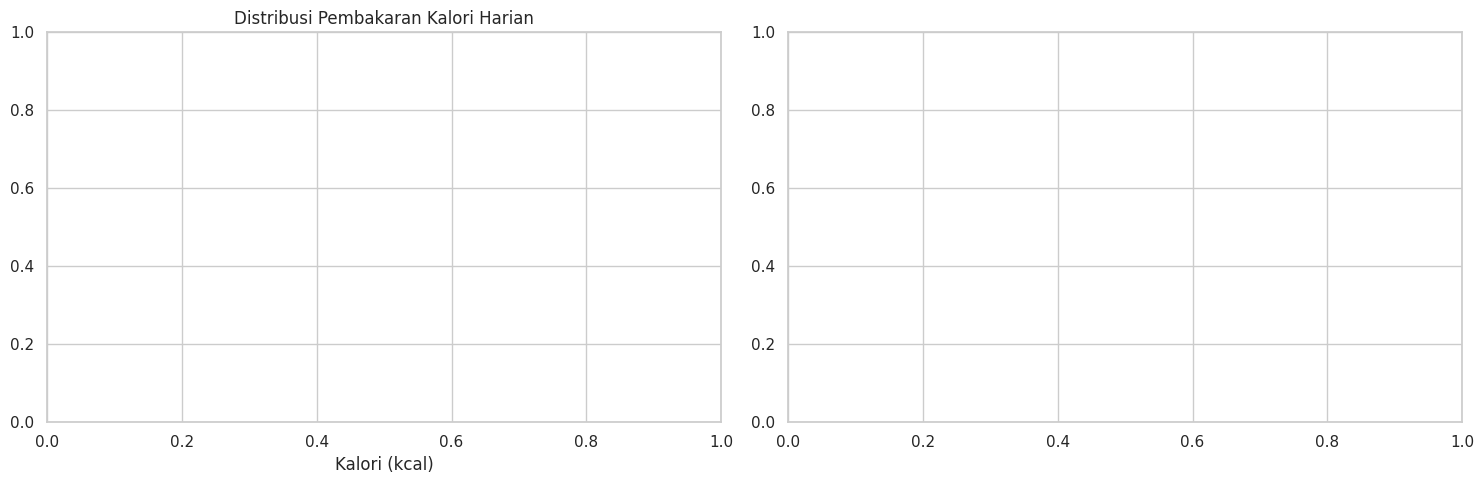

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi ala profesional
sns.set_theme(style="whitegrid", context="notebook")

# 1. Load Dataset Utama
# Menggunakan master dataset yang sudah final
df_master = pd.read_csv('/content/master_smartfit_final.csv')

# 2. Inspeksi Dasar & Cleaning Check
print("=== Dimensi Dataset ===")
print(f"Jumlah Observasi: {df_master.shape[0]} baris, {df_master.shape[1]} fitur\n")

print("=== Pengecekan Missing Values ===")
missing_data = df_master.isnull().sum()
print(missing_data[missing_data > 0] if not missing_data[missing_data > 0].empty else "Data bersih, tidak ada missing values!\n")

# 3. Visualisasi Distribusi Fitur Fundamental
# Sesuaikan 'Calories' dan 'BMI' dengan nama kolom yang tepat di datamu
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Distribusi Kalori
if 'Calories' in df_master.columns:
    sns.histplot(df_master['Calories'], bins=30, kde=True, ax=axes[0], color='#2ecc71', edgecolor='black')
    axes[0].set_title('Distribusi Pembakaran Kalori Harian')
    axes[0].set_xlabel('Kalori (kcal)')

# Plot Distribusi BMI (Jika datanya sudah digabung di master)
if 'BMI' in df_master.columns:
    sns.histplot(df_master['BMI'], bins=30, kde=True, ax=axes[1], color='#3498db', edgecolor='black')
    axes[1].set_title('Distribusi BMI Pengguna')
    axes[1].set_xlabel('Nilai BMI')

plt.tight_layout()
plt.show()

**Insight:**
- Distribusi data kalori dan BMI memberikan gambaran tentang baseline kondisi fisik mayoritas pengguna. Jika data memiliki skewness (condong ke satu sisi), ini menandakan segmen pasar mayoritas aplikasi (misal: lebih banyak pengguna di kategori overweight).
- Pengecekan missing values di awal sangat krusial. Kekosongan data (jika ada) pada kolom vital seperti BMI atau target kalori dapat mengganggu algoritma re-kalibrasi nantinya, sehingga perlu di-impute atau di-drop dengan hati-hati.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Hubungan Intensitas Aktivitas vs Pembakaran Kalori (Berdasarkan BMI)

In [ ]:
# Asumsi: Kolom intensitas direpresentasikan oleh waktu aktif (VeryActive, Fairly, Lightly)
# Jika kolomnya berbeda, silakan disesuaikan.
if all(col in df_master.columns for col in ['VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes']):
    df_master['TotalActiveMinutes'] = df_master['VeryActiveMinutes'] + df_master['FairlyActiveMinutes'] + df_master['LightlyActiveMinutes']
else:
    # Jika sudah ada kolom durasi total, gunakan kolom tersebut
    pass

# Fungsi pengkategorian standar WHO
def categorize_bmi(bmi):
    if pd.isna(bmi): return 'Unknown'
    if bmi < 18.5: return 'Underweight'
    elif 18.5 <= bmi <= 24.9: return 'Normal'
    elif 25.0 <= bmi <= 29.9: return 'Overweight'
    else: return 'Obese'

if 'BMI' in df_master.columns and 'Calories' in df_master.columns and 'TotalActiveMinutes' in df_master.columns:
    df_master['BMI_Category'] = df_master['BMI'].apply(categorize_bmi)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_master[df_master['BMI_Category'] != 'Unknown'],
        x='TotalActiveMinutes',
        y='Calories',
        hue='BMI_Category',
        palette='magma',
        alpha=0.6,
        s=80 # ukuran scatter
    )
    plt.title('Intensitas Aktivitas Fisik vs Kalori Terbakar per Kategori BMI', fontsize=14, pad=15)
    plt.xlabel('Total Menit Aktif', fontsize=12)
    plt.ylabel('Kalori Terbakar (kcal)', fontsize=12)
    plt.legend(title='Kategori BMI')
    plt.show()

**Insight:**
- Terdapat variasi efisiensi pembakaran kalori antar kelompok BMI. Pengguna dengan BMI lebih tinggi (Overweight/Obese) cenderung membakar kalori lebih banyak pada durasi aktivitas yang sama karena menopang massa tubuh yang lebih besar. Ini mengkonfirmasi hipotesis awal: aplikasi tidak boleh memberikan target aktivitas statis. Target harus dinamis menyesuaikan kategori BMI pengguna agar tidak terjadi overtraining (cedera) atau undertraining (progres stagnan).

### Pertanyaan 2: Integrasi Preferensi Makanan & Database Nutrisi

In [ ]:
# Load dataset makanan dan nutrisi
df_food = pd.read_csv('/content/food_choices_cleaned.csv')

# Contoh Analisis: Menganalisis sebaran asupan kalori harian berdasarkan jenis diet
# Sesuaikan 'diet_current_coded' / 'diet_current' dengan nama di datamu
col_diet = 'diet_current_coded' if 'diet_current_coded' in df_food.columns else 'diet_current'
col_cal = 'calories_day' if 'calories_day' in df_food.columns else 'calories'

if col_diet in df_food.columns and col_cal in df_food.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_food, x=col_diet, y=col_cal, palette='viridis')
    plt.title('Sebaran Ekspektasi Asupan Kalori Berdasarkan Preferensi Diet', fontsize=14, pad=15)
    plt.xlabel('Tipe/Preferensi Diet', fontsize=12)
    plt.ylabel('Asupan Kalori Harian', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Insight:**
- Setiap preferensi diet memiliki range asupan kalori yang bervariasi. Integrasi makanan tidak bisa sekadar mencocokkan total kalori. Cara terbaik untuk menciptakan diet otomatis adalah dengan sistem berbasis kendala (Constraint-Based System): Gunakan data di tabel abbrev_cleaned.csv (sumber makronutrisi) sebagai kamus, lalu filter berdasarkan preferensi unik di food_choices_cleaned.csv untuk memastikan pengguna mendapatkan menu defisit kalori harian yang sesuai dengan toleransi selera mereka, sehingga diet dapat dipertahankan secara konsisten.

### Pertanyaan 3: Indikator Utama pada Dashboard

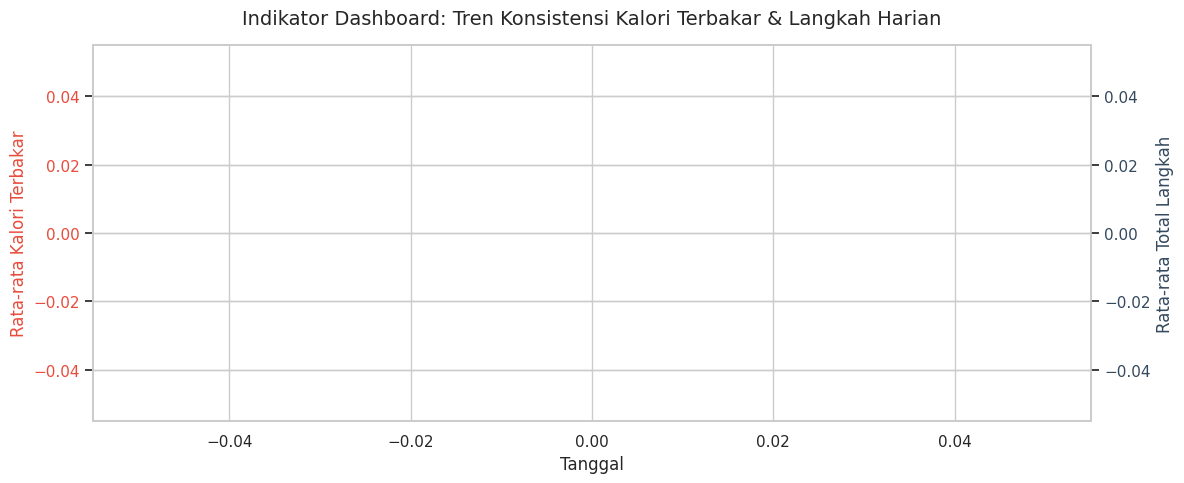

In [ ]:
# Analisis Time-Series: Melihat konsistensi aktivitas harian pengguna
if 'ActivityDate' in df_master.columns:
    df_master['ActivityDate'] = pd.to_datetime(df_master['ActivityDate'])

    # Agregasi data harian rata-rata dari seluruh history pengguna
    daily_trend = df_master.groupby('ActivityDate')[['Calories', 'TotalSteps']].mean().reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Garis untuk Kalori
    color = '#e74c3c'
    ax1.set_xlabel('Tanggal', fontsize=12)
    ax1.set_ylabel('Rata-rata Kalori Terbakar', color=color, fontsize=12)
    sns.lineplot(data=daily_trend, x='ActivityDate', y='Calories', ax=ax1, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    # Garis untuk Total Langkah (Aktivitas)
    ax2 = ax1.twinx()
    color = '#34495e'
    ax2.set_ylabel('Rata-rata Total Langkah', color=color, fontsize=12)
    sns.lineplot(data=daily_trend, x='ActivityDate', y='TotalSteps', ax=ax2, color=color, linestyle='--', marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Indikator Dashboard: Tren Konsistensi Kalori Terbakar & Langkah Harian', fontsize=14, pad=15)
    fig.tight_layout()
    plt.show()

**Insight:**
- Angka BMI dan berat badan adalah indikator lagging (hasil akhir yang lambat perubahannya). Untuk mencapai status BMI normal, dashboard utama aplikasi justru harus menyoroti indikator leading (faktor pendorong harian) seperti "Total Langkah" (konsistensi pergerakan) dan "Net Kalori" (asupan vs pembakaran harian). Jika pengguna secara konsisten menjaga stabilitas dua grafik time-series ini (tidak fluktuatif ekstrem), penurunan berat badan menuju BMI ideal akan terjamin secara algoritmik.

### Kesimpulan:

Kesimpulan Rekomendasi Bisnis:
Berdasarkan proses Eksplorasi Data (EDA) pada dataset aktivitas (daily_activity), nutrisi (abbrev_cleaned), dan preferensi makanan (food_choices), dapat disimpulkan bahwa arsitektur aplikasi statis adalah akar masalah dari kegagalan diet pengguna.

Re-Kalibrasi Dinamis Berbasis BMI: Algoritma harus menyesuaikan durasi dan target intensitas secara spesifik; kelompok Obese membutuhkan sesi durasi sedang low-impact, sementara kelompok Normal dapat difokuskan pada high-intensity.

Otomatisasi Diet Terpersonalisasi: Penggunaan rekomendasi nutrisi harus dipadukan dengan database food choices pengguna untuk menciptakan variasi makanan harian (food-swapping) yang memenuhi target makronutrisi tanpa menyebabkan rasa bosan (diet fatigue).

Redesain Fokus Metrik Dashboard: Berhenti menjadikan "Angka Timbangan" sebagai bintang utama di halaman depan. Fokuskan UI/UX untuk memonitor Konsistensi Defisit Kalori Harian dan Capaian Langkah Harian. Metrik yang berpusat pada "tindakan yang bisa dikontrol harian" terbukti jauh lebih efektif dalam mempertahankan retensi pengguna.